In [1]:
import importlib

import numpy as np
import random
import time
import pandas as pd
import os
import random
from tqdm import tqdm


# Signals
from scipy.stats import mannwhitneyu
from scipy import signal
from scipy.fft import fftshift
from scipy.signal import welch

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  


from matplotlib.colors import Normalize, LogNorm

import auxlib; importlib.reload(auxlib)

<module 'auxlib' from 'c:\\Users\\Usuario\\Desktop\\tandil\\auxlib.py'>

# Time analysis

We start by graphing raw data for task 1 (runs = 3, 7 and 11) in a couple of sessions 

In [2]:
def task_labels(header):	
	t0_labels = []
	t1_labels = []
	t2_labels = []
	for task in range(len(header['annotations'])):
		if header['annotations'][task][2] == 'T1':
			t1_labels.append(header['annotations'][task][0])
		elif header['annotations'][task][2] == 'T2':
			t2_labels.append(header['annotations'][task][0])
		else:
			t0_labels.append(header['annotations'][task][0])
	return t0_labels, t1_labels, t2_labels

In [3]:
def showEEG(signals, ti, tf, time, electrodes=[1, 2, 3, 4, 5, 6, 7, 8, 9]):
	fig, axes = plt.subplots(len(electrodes), 1, figsize=(20, len(electrodes)), sharex=True)

	for ax, i in zip(axes, electrodes):
		ax.plot(time[ti:tf], signals[i][ti:tf], color='purple')

		# Remove axis frames and ticks
		ax.spines['top'].set_visible(False)
		ax.spines['right'].set_visible(False)
		ax.spines['left'].set_visible(False)
		ax.spines['bottom'].set_visible(False)
		ax.set_yticks([])
		ax.set_xticks([])

		# Add channel label to the left
		ax.text(-0.02, 0.5, f'Ch {i+1}', transform=ax.transAxes, fontsize=14, 
				verticalalignment='center', horizontalalignment='right')
		for t1 in t1_labels:
			ax.axvline(x=t1, color='red')
		for t2 in t2_labels:
			ax.axvline(x=t2, color='blue')
		for t0 in t0_labels:
			ax.axvline(x=t0, color='black')
	# Show only the last x-axis
	axes[-1].spines['bottom'].set_visible(True)
	axes[-1].set_xlim(time[ti], time[tf-1])
	axes[-1].set_xticks(range(0, int((tf - ti)/160), max(1, (tf - ti) // 4800)))  # Adjust tick marks
	axes[-1].set_xlabel("Time (s)", fontsize=14)

	plt.subplots_adjust(left=0.05)  # Adjust layout to fit labels
	#plt.show()
	return fig

Choosing the sessions we will use

In [ ]:
sessions = [10] # [10, 20, 43, 60, 86, 99]
main_electrodes = [10, 31, 36, 42, 43, 48, 53, 63]

C:\Users\Usuario\AppData\Local\Temp/ipykernel_2544/544438892.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(len(electrodes), 1, figsize=(20, len(electrodes)), sharex=True)


MemoryError: In RendererAgg: Out of memory

<Figure size 1440x4608 with 0 Axes>

<Figure size 1440x576 with 0 Axes>

<Figure size 1440x576 with 0 Axes>

...

<Figure size 1440x576 with 0 Axes>

<Figure size 1440x576 with 0 Axes>

<Figure size 1440x4608 with 0 Axes>

<Figure size 1440x576 with 0 Axes>

<Figure size 1440x576 with 0 Axes>

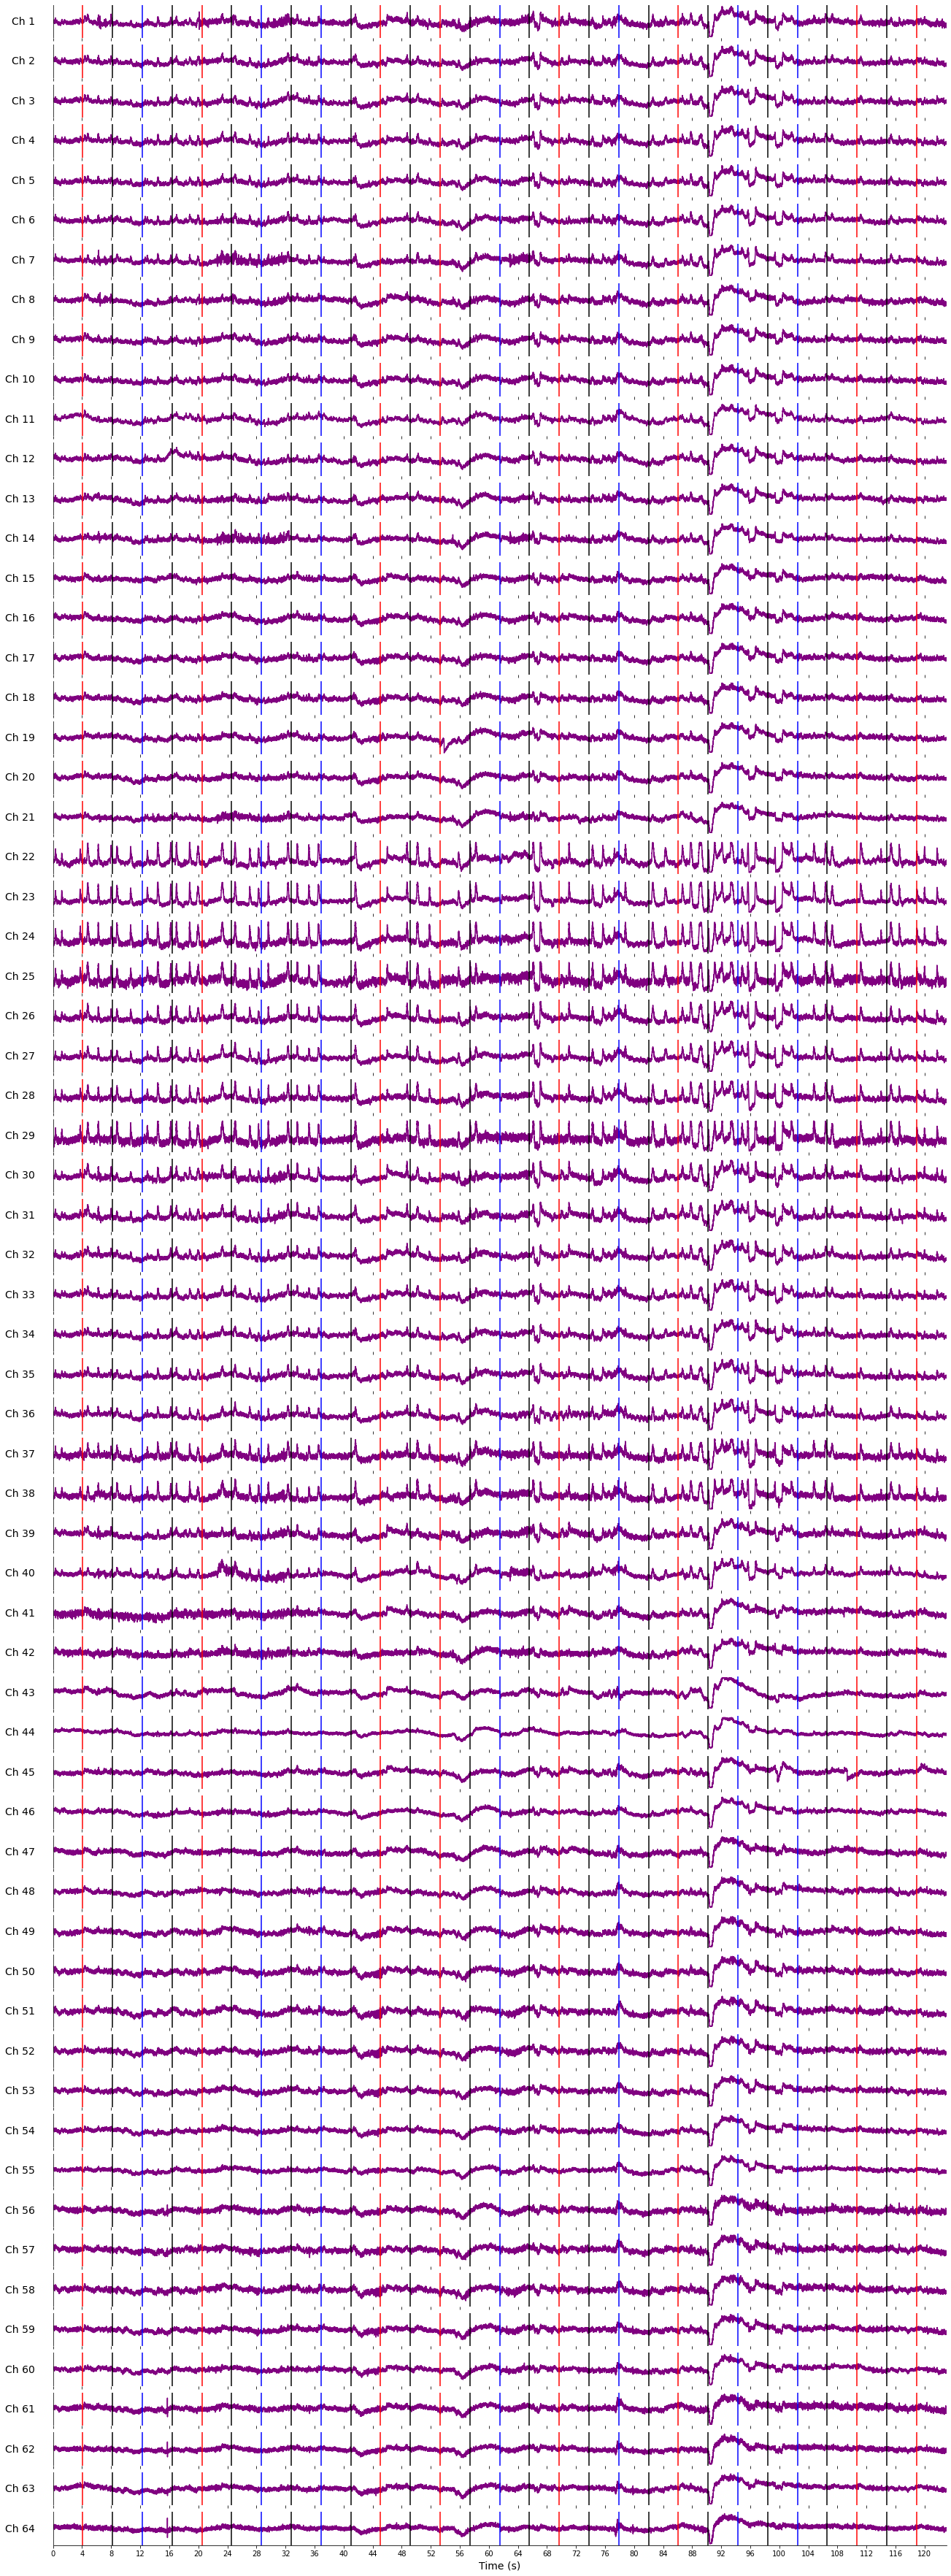

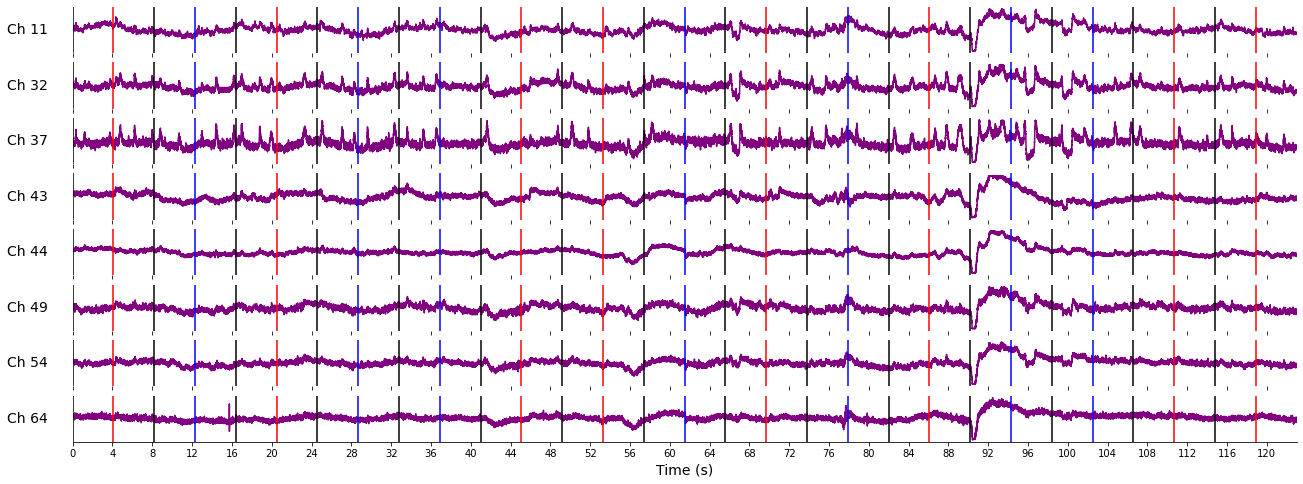

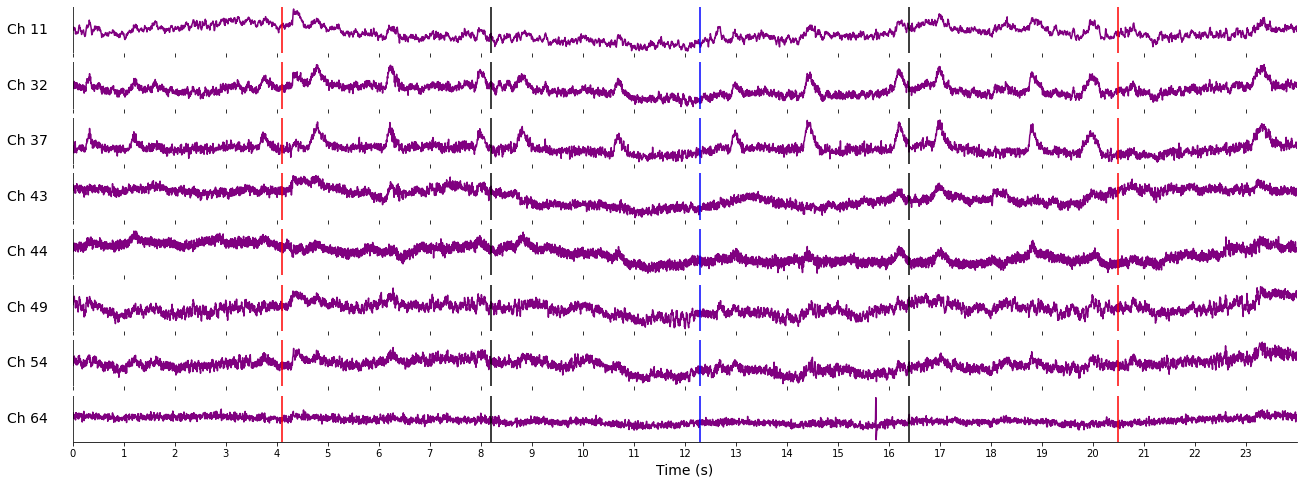

In [5]:
for session in sessions:
	for run in [3, 7, 11]:
		data, signal_headers, header = auxlib.loadEEG(subject=session, record=run)
		t0_labels, t1_labels, t2_labels = task_labels(header)
		time = np.linspace(0, len(data[0])/160, len(data[0]))
		pd.DataFrame(data, ).to_csv(f'media/S{session:03d}R{run:02d}.csv')
		
		fig = showEEG(data, 0, len(data[0]), time, range(64))
		fig2 = showEEG(data, 0, len(data[0]), time, [10, 31, 36, 42, 43, 48, 53, 63])
		fig2_zoom = showEEG(data, 0, 1280*3, time, [10, 31, 36, 42, 43, 48, 53, 63])

		fig.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_time.png'), bbox_inches='tight', dpi=300)
		fig2.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_time_fewChannels.png'), bbox_inches='tight', dpi=300)
		fig2_zoom.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_time_zoom.png'), bbox_inches='tight', dpi=300)

		fig.clf()
		fig2.clf()
		fig2_zoom.clf()

# Freq analysis

In [ ]:
fs = 160.0
norm = Normalize(vmin=0, vmax=10000)

In [ ]:
sessions = [10]

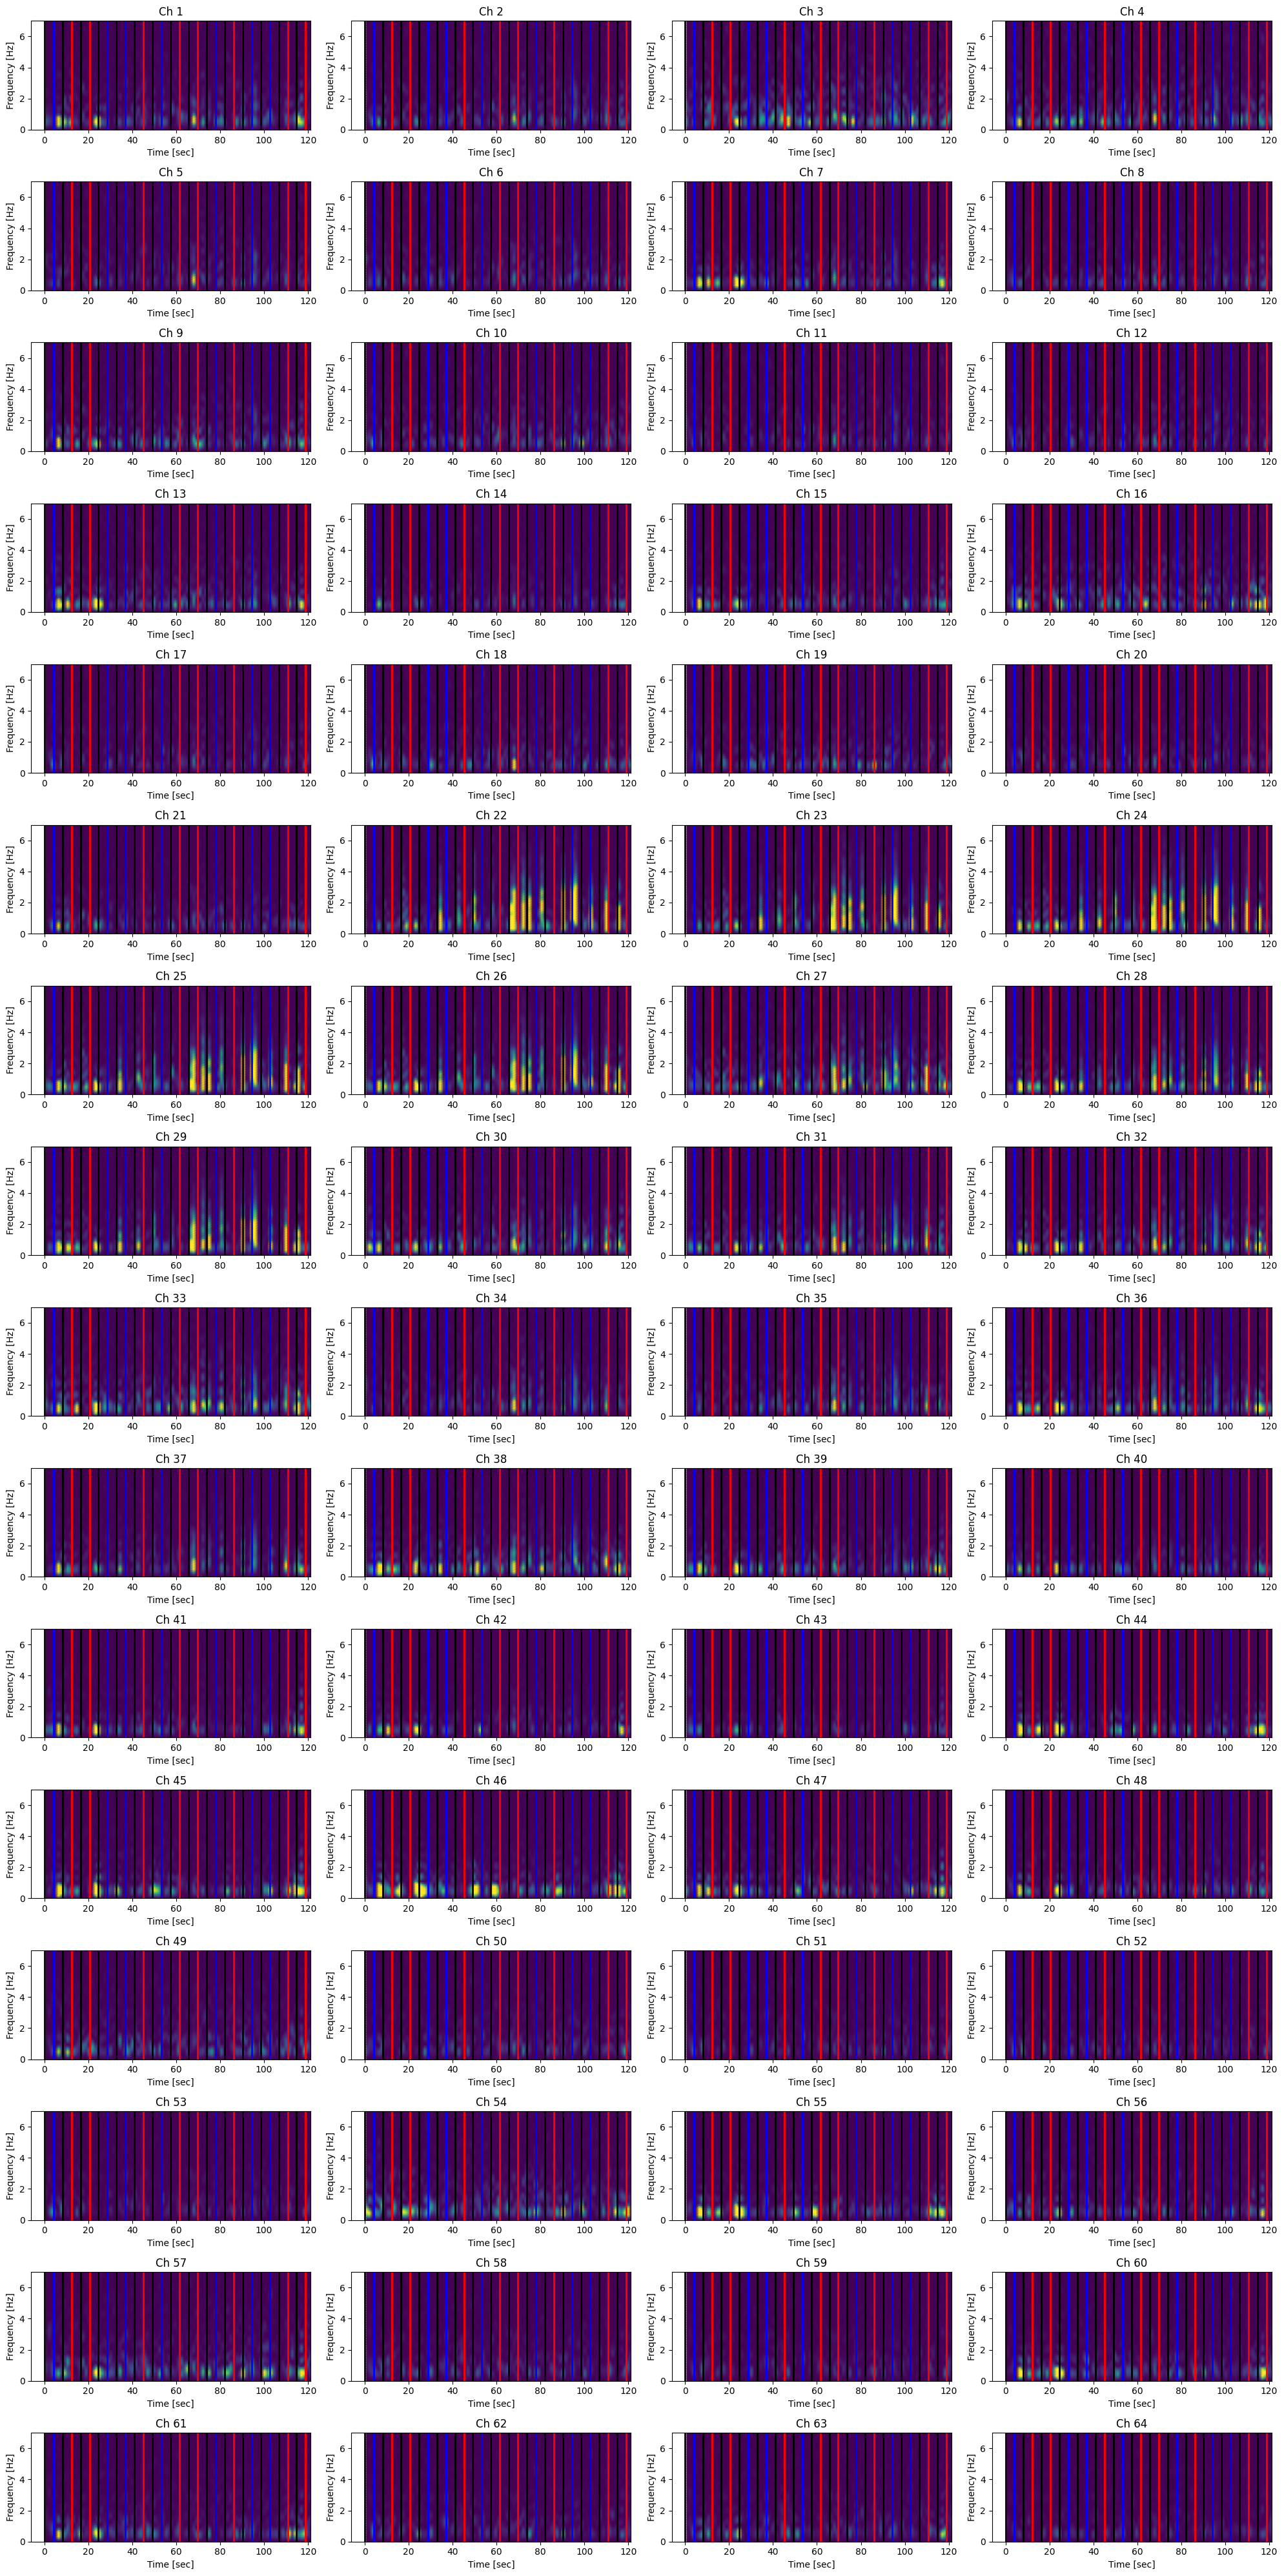

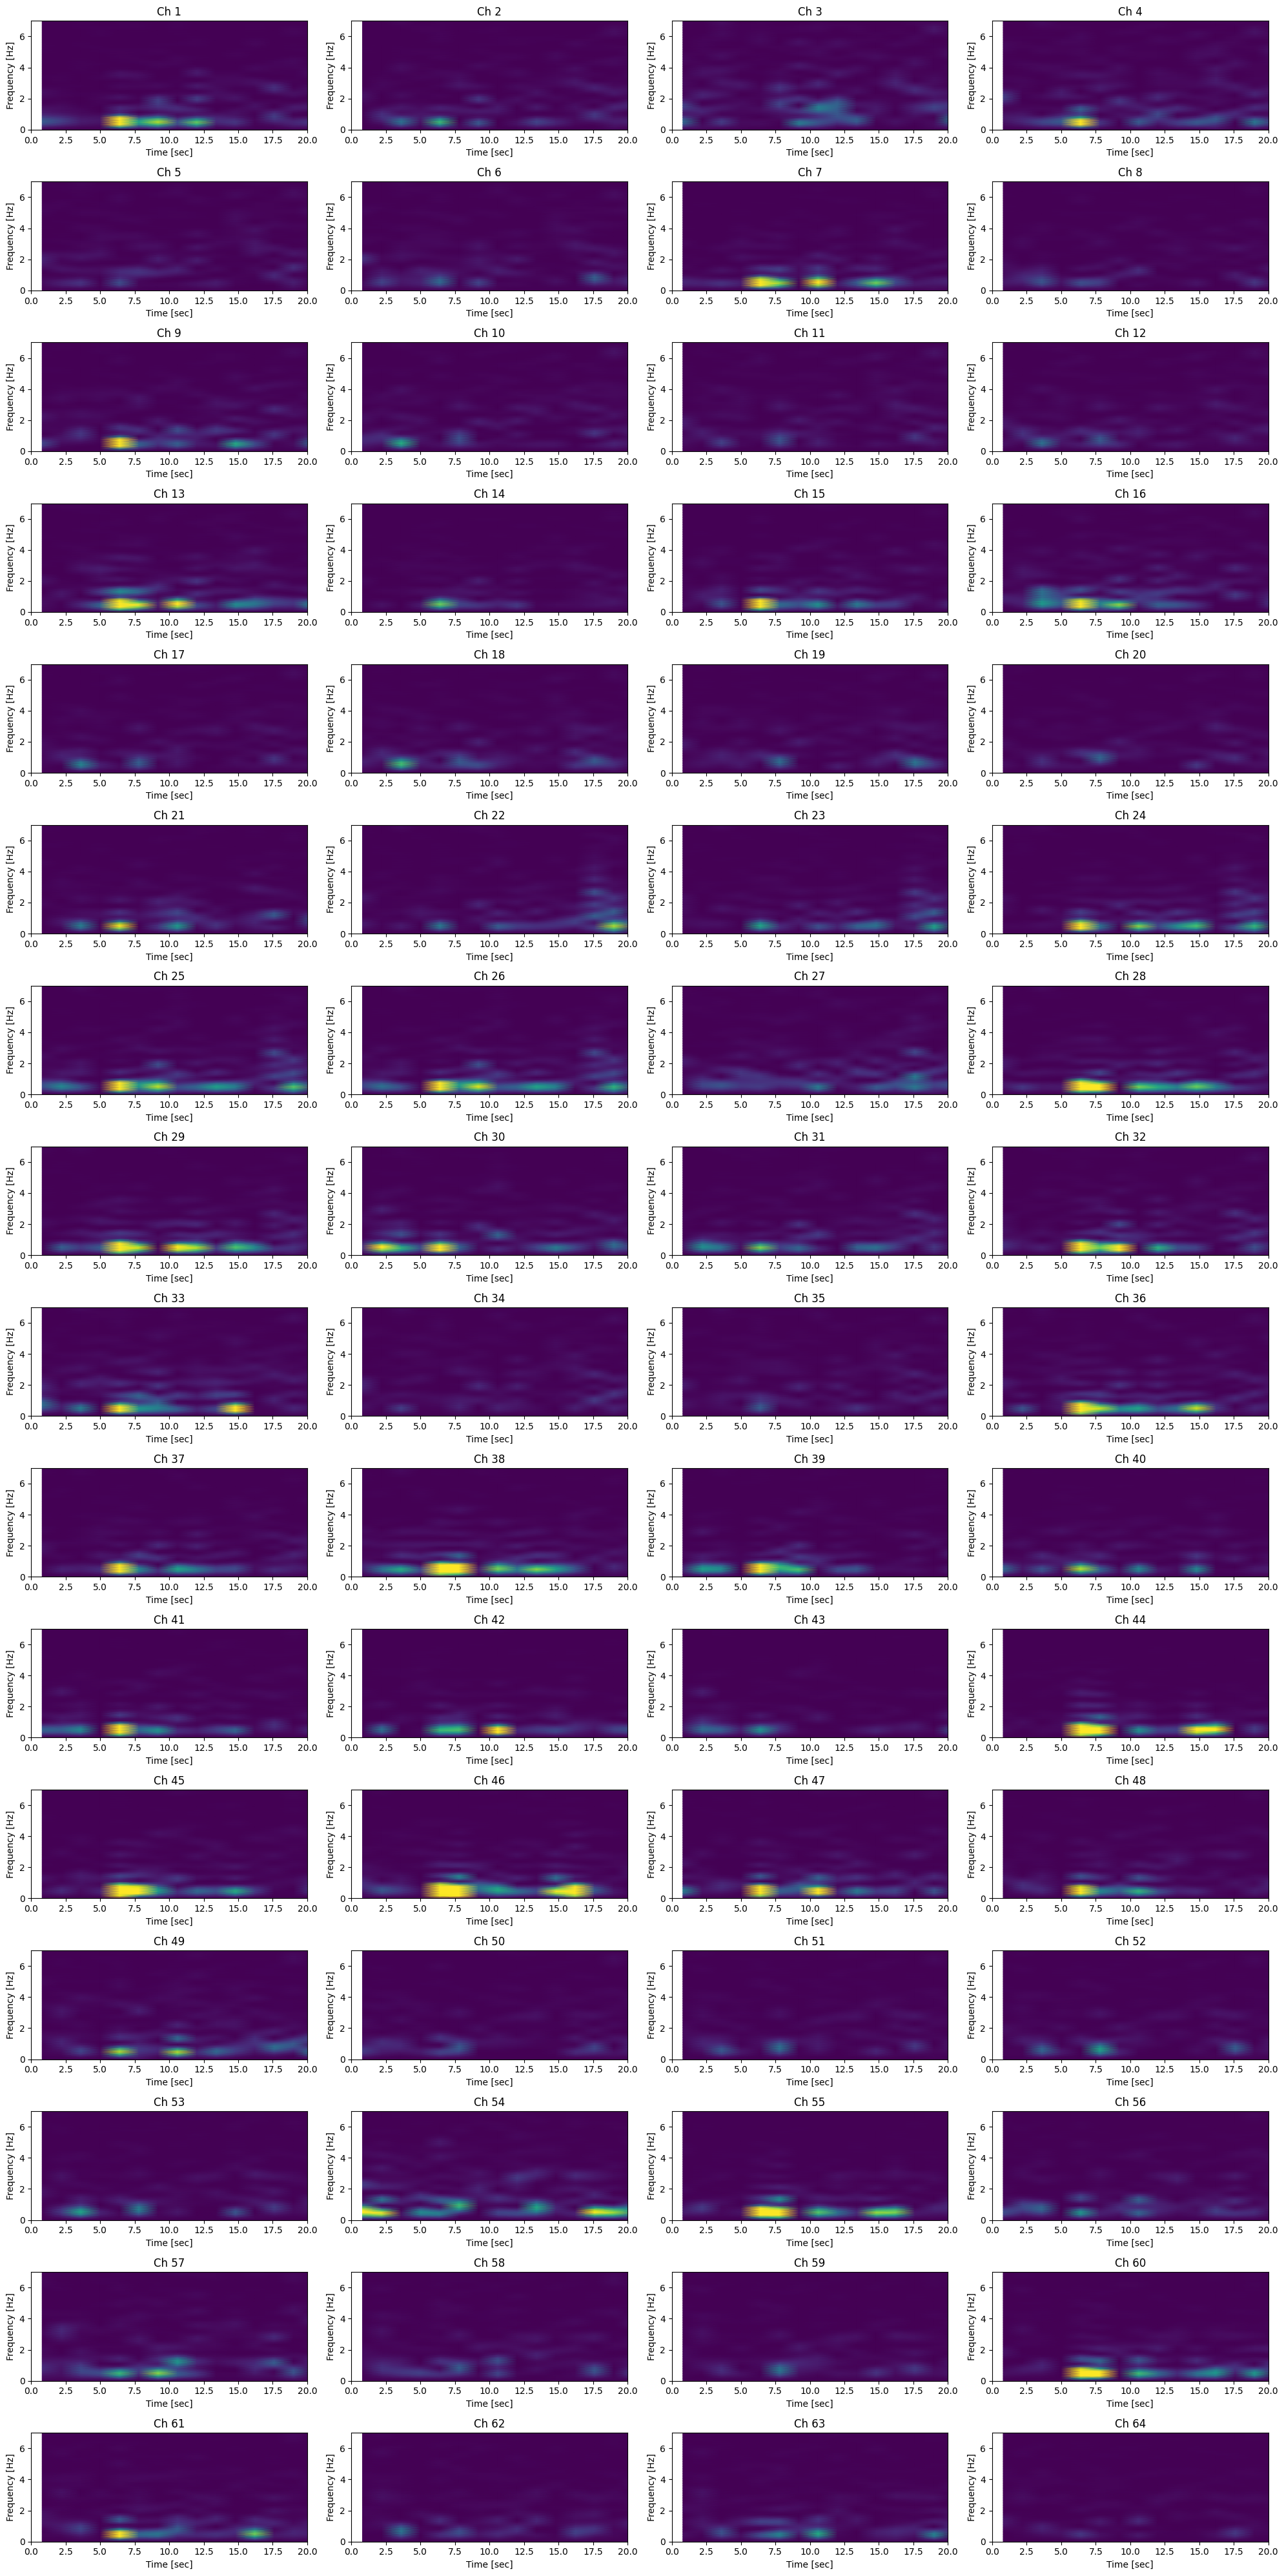

In [ ]:
for session in sessions:
	for run in [3]:#, 7, 11]:
		data, signal_headers, header = auxlib.loadEEG(subject=session, record=run)
		t0_labels, t1_labels, t2_labels = task_labels(header)

		fig, axs = plt.subplots(16, 4, figsize=(20, 40))
		for ch in range(1, 65):
			x = data[ch-1]
			f, t, Sxx = signal.spectrogram(x, fs, nfft=1024, noverlap=32)

			axs[(ch-1)//4, (ch-1)%4].pcolormesh(t, f, Sxx, shading='gouraud', cmap='viridis', norm=norm)
			axs[(ch-1)//4, (ch-1)%4].set_ylabel('Frequency [Hz]')
			axs[(ch-1)//4, (ch-1)%4].set_ylim(0, 7)
			axs[(ch-1)//4, (ch-1)%4].set_xlabel('Time [sec]')
			axs[(ch-1)//4, (ch-1)%4].set_title("Ch {}".format(ch))
			for t1 in t1_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t1, color='red', linewidth = 2.0)
			for t2 in t2_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t2, color='blue', linewidth = 2.0)
			for t0 in t0_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t0, color='black', linewidth = 2.0)
		fig.tight_layout()

		fig2, axs = plt.subplots(16, 4, figsize=(20, 40))
		for ch in range(1, 65):
			x = data[ch-1]
			f, t, Sxx = signal.spectrogram(x, fs, nfft=1024, noverlap=32)

			axs[(ch-1)//4, (ch-1)%4].pcolormesh(t, f, Sxx, shading='gouraud', cmap='viridis', norm=norm)
			axs[(ch-1)//4, (ch-1)%4].set_ylabel('Frequency [Hz]')
			axs[(ch-1)//4, (ch-1)%4].set_ylim(0, 7)
			axs[(ch-1)//4, (ch-1)%4].set_xlim(0, 20)
			axs[(ch-1)//4, (ch-1)%4].set_xlabel('Time [sec]')
			axs[(ch-1)//4, (ch-1)%4].set_title("Ch {}".format(ch))
			for t1 in t1_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t1, color='red', linewidth = 2.0)
			for t2 in t2_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t2, color='blue', linewidth = 2.0)
			for t0 in t0_labels:
				axs[(ch-1)//4, (ch-1)%4].axvline(x=t0, color='black', linewidth = 2.0)
		fig2.tight_layout()

		fig3, axs = plt.subplots(16, 4, figsize=(20, 10))
		for ch in [10, 31, 36, 42, 43, 48, 53, 63]:
			x = data[ch]
			f, t, Sxx = signal.spectrogram(x, fs, nfft=1024, noverlap=32)

			axs[(ch)//4, (ch)%4].pcolormesh(t, f, Sxx, shading='gouraud', cmap='viridis', norm=norm)
			axs[(ch)//4, (ch)%4].set_ylabel('Frequency [Hz]')
			axs[(ch)//4, (ch)%4].set_ylim(0, 7)
			axs[(ch)//4, (ch)%4].set_xlim(0, 20)
			axs[(ch)//4, (ch)%4].set_xlabel('Time [sec]')
			axs[(ch)//4, (ch)%4].set_title("Ch {}".format(ch))
			for t1 in t1_labels:
				axs[(ch)//4, (ch)%4].axvline(x=t1, color='red', linewidth = 2.0)
			for t2 in t2_labels:
				axs[(ch)//4, (ch)%4].axvline(x=t2, color='blue', linewidth = 2.0)
			for t0 in t0_labels:
				axs[(ch)//4, (ch)%4].axvline(x=t0, color='black', linewidth = 2.0)
		fig3.tight_layout()

		fig.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_spectrogram.png'), bbox_inches='tight', dpi=300)
		fig2.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_spectrogram_zoom.png'), bbox_inches='tight', dpi=300)
		fig3.savefig(os.path.join('media', f'S{session:03d}R{run:02d}_spectrogram_zoom.png'), bbox_inches='tight', dpi=300)

		fig.clf()
		fig2.clf()
		fig3.clf()